##EDA

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Path to dataset files: /kaggle/input/creditcardfraud


In [2]:
import os
print(os.listdir(path))

['creditcard.csv']


In [4]:
import pandas as pd
new_p=os.path.join(path,'creditcard.csv')

df=pd.read_csv(new_p)
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [6]:
fraud = df['Class'].value_counts()

fraud_count = fraud[1]
normal_count = fraud[0]

total = len(df)

fraud_pct = fraud_count / total * 100
normal_pct = normal_count / total * 100

print("Fraud %:", fraud_pct)
print("Legitimate %:", normal_pct)

Fraud %: 0.1727485630620034
Legitimate %: 99.82725143693798


In [7]:
ratio = normal_count / fraud_count

print("Imbalance Ratio:", ratio)

Imbalance Ratio: 577.8760162601626


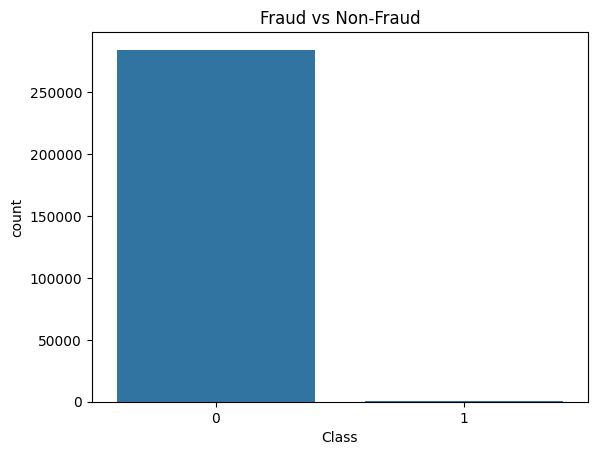

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='Class', data=df)

plt.title("Fraud vs Non-Fraud")
plt.show()

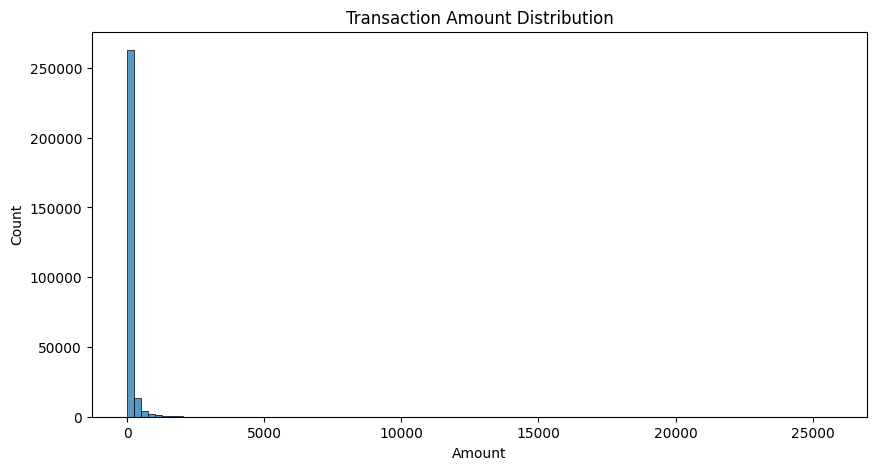

In [9]:
plt.figure(figsize=(10,5))

sns.histplot(df['Amount'], bins=100)

plt.title("Transaction Amount Distribution")
plt.show()

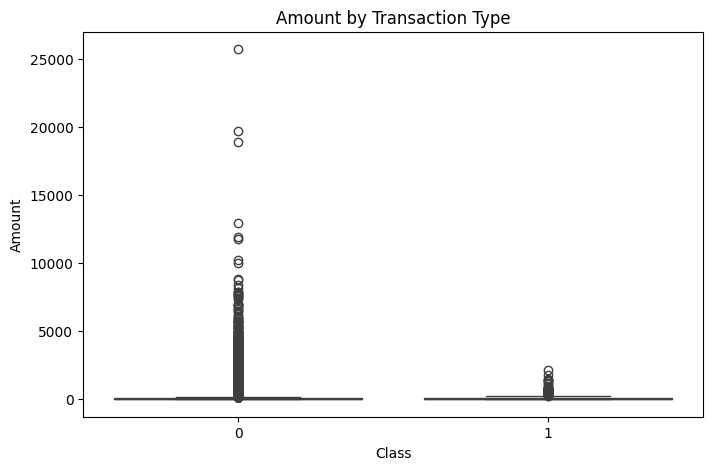

In [10]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Class', y='Amount', data=df)

plt.title("Amount by Transaction Type")
plt.show()

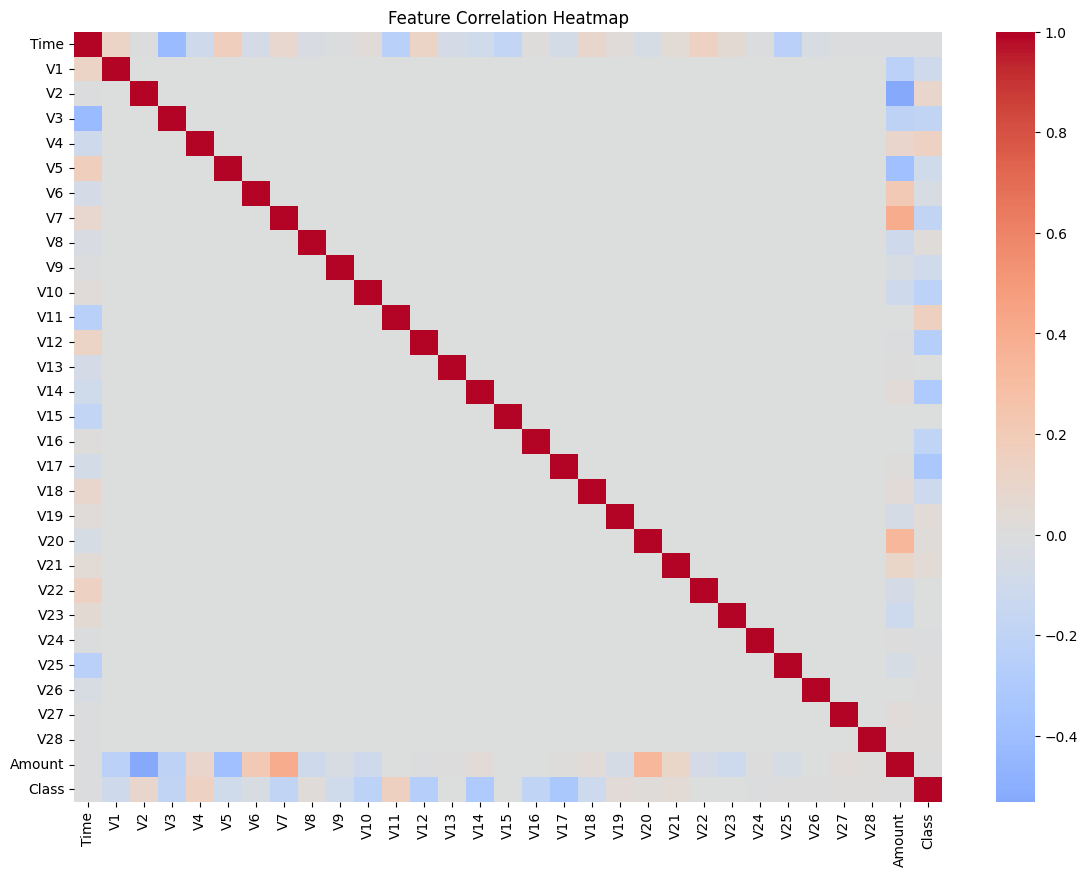

In [11]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(),
    cmap='coolwarm',
    center=0
)

plt.title("Feature Correlation Heatmap")
plt.show()

##Sequence Generation

In [12]:
df = df.sort_values('Time')

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df['Amount'] = scaler.fit_transform(
    df[['Amount']]
)

In [14]:
features = df.drop('Class', axis=1).values

target = df['Class'].values

In [15]:
import numpy as np

SEQ_LEN = 5

X = []
y = []

for i in range(len(df)-SEQ_LEN):

    X.append(features[i:i+SEQ_LEN])

    y.append(target[i+SEQ_LEN])

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(284802, 5, 30)
(284802,)


##Build Models

In [16]:
split_idx = int(len(X) * 0.8)

X_train = X[:split_idx]
X_test = X[split_idx:]

y_train = y[:split_idx]
y_test = y[split_idx:]

print(X_train.shape)
print(X_test.shape)

(227841, 5, 30)
(56961, 5, 30)


In [17]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weights = {
    0: weights[0],
    1: weights[1]
}

print(class_weights)

{0: np.float64(0.5009167897847193), 1: np.float64(273.1906474820144)}


In [19]:
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    average_precision_score
)

def evaluate_model(model, X_test, y_test):

    probs = model.predict(X_test)

    preds = (probs > 0.5).astype(int)

    print(classification_report(y_test, preds))

    roc = roc_auc_score(y_test, probs)

    pr_auc = average_precision_score(
        y_test,
        probs
    )

    print("ROC-AUC :", roc)
    print("PR-AUC  :", pr_auc)

###MODEL A: Dense Neural Network

In [20]:
X_train_dense = X_train.reshape(
    X_train.shape[0],
    -1
)

X_test_dense = X_test.reshape(
    X_test.shape[0],
    -1
)

In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

dense_model = Sequential([

    Dense(
        128,
        activation='relu',
        input_shape=(150,)
    ),

    Dropout(0.3),

    Dense(
        64,
        activation='relu'
    ),

    Dropout(0.3),

    Dense(
        1,
        activation='sigmoid'
    )
])

dense_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['AUC']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [22]:
history_dense = dense_model.fit(
    X_train_dense,
    y_train,
    epochs=10,
    batch_size=256,
    validation_split=0.2,
    class_weight=class_weights
)

Epoch 1/10
712/712 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - AUC: 0.5036 - loss: 1016.3784 - val_AUC: 0.5000 - val_loss: 60.8838
Epoch 2/10
712/712 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - AUC: 0.5124 - loss: 69.8511 - val_AUC: 0.5052 - val_loss: 2.0946
Epoch 3/10
712/712 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - AUC: 0.4931 - loss: 17.5491 - val_AUC: 0.5351 - val_loss: 1.6069
Epoch 4/10
712/712 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - AUC: 0.4973 - loss: 7.2683 - val_AUC: 0.5000 - val_loss: 0.7929
Epoch 5/10
712/712 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - AUC: 0.5038 - loss: 3.4582 - val_AUC: 0.5000 - val_loss: 0.7980
Epoch 6/10
712/712 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - AUC: 0.4874 - loss: 2.3791 - val_AUC: 0.5000 - val_loss: 0.7898
Epoch 7/10
712/712 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - AUC: 0.4915 - loss: 2.2116 - val_AUC: 0.5000 - val_loss: 0.7742
Epoch 8/10
712/712 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - AUC: 0.4894 - loss: 4.2999 - val_AUC: 0.5000 - val_loss: 0.7724
Epoch 9/10
712/712 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/ste

In [23]:
evaluate_model(
    dense_model,
    X_test_dense,
    y_test
)

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
              precision    recall  f1-score   support

           0       0.00      0.00      0.00     56886
           1       0.00      1.00      0.00        75

    accuracy                           0.00     56961
   macro avg       0.00      0.50      0.00     56961
weighted avg       0.00      0.00      0.00     56961

ROC-AUC : 0.5
PR-AUC  : 0.0013166903670932743


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### MODEL B: LSTM

In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

lstm_model = Sequential([

    LSTM(
        64,
        input_shape=(
            X_train.shape[1],
            X_train.shape[2]
        )
    ),

    Dropout(0.3),

    Dense(
        32,
        activation='relu'
    ),

    Dense(
        1,
        activation='sigmoid'
    )
])

lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['AUC']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [25]:
history_lstm = lstm_model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=256,
    validation_split=0.2,
    class_weight=class_weights
)

Epoch 1/10
712/712 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - AUC: 0.4844 - loss: 0.8221 - val_AUC: 0.5000 - val_loss: 0.7724
Epoch 2/10
712/712 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - AUC: 0.4676 - loss: 0.7624 - val_AUC: 0.5000 - val_loss: 0.6576
Epoch 3/10
712/712 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - AUC: 0.4982 - loss: 0.7369 - val_AUC: 0.5000 - val_loss: 0.7436
Epoch 4/10
712/712 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - AUC: 0.4947 - loss: 0.7304 - val_AUC: 0.5000 - val_loss: 0.6493
Epoch 5/10
712/712 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - AUC: 0.5035 - loss: 0.7281 - val_AUC: 0.5000 - val_loss: 0.8103
Epoch 6/10
712/712 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - AUC: 0.5086 - loss: 0.7302 - val_AUC: 0.5000 - val_loss: 0.7422
Epoch 7/10
712/712 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - AUC: 0.4702 - loss: 0.7295 - val_AUC: 0.5000 - val_loss: 0.7548
Epoch 8/10
712/712 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - AUC: 0.4860 - loss: 0.7278 - val_AUC: 0.5000 - val_loss: 0.6949
Epoch 9/10
712/712 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/s

In [26]:
evaluate_model(
    lstm_model,
    X_test,
    y_test
)

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
              precision    recall  f1-score   support

           0       0.00      0.00      0.00     56886
           1       0.00      1.00      0.00        75

    accuracy                           0.00     56961
   macro avg       0.00      0.50      0.00     56961
weighted avg       0.00      0.00      0.00     56961

ROC-AUC : 0.5
PR-AUC  : 0.0013166903670932743


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


###MODEL C: LSTM + Attention

In [27]:
import tensorflow as tf
from tensorflow.keras.layers import Layer

class AttentionLayer(Layer):

    def build(self, input_shape):

        self.W = self.add_weight(
            shape=(input_shape[-1], 1),
            initializer='random_normal',
            trainable=True
        )

        self.b = self.add_weight(
            shape=(input_shape[1], 1),
            initializer='zeros',
            trainable=True
        )

    def call(self, inputs):

        score = tf.nn.tanh(
            tf.tensordot(
                inputs,
                self.W,
                axes=1
            ) + self.b
        )

        weights = tf.nn.softmax(
            score,
            axis=1
        )

        context = tf.reduce_sum(
            weights * inputs,
            axis=1
        )

        return context

In [28]:
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM
from tensorflow.keras.models import Model

inputs = Input(
    shape=(
        X_train.shape[1],
        X_train.shape[2]
    )
)

x = LSTM(
    64,
    return_sequences=True
)(inputs)

context = AttentionLayer()(x)

x = Dense(
    32,
    activation='relu'
)(context)

outputs = Dense(
    1,
    activation='sigmoid'
)(x)

attention_model = Model(
    inputs,
    outputs
)

attention_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['AUC']
)

In [29]:
history_attention = attention_model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=256,
    validation_split=0.2,
    class_weight=class_weights
)

Epoch 1/10
712/712 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - AUC: 0.5282 - loss: 0.7565 - val_AUC: 0.5000 - val_loss: 1.1787
Epoch 2/10
712/712 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - AUC: 0.4806 - loss: 0.7381 - val_AUC: 0.5000 - val_loss: 0.5502
Epoch 3/10
712/712 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - AUC: 0.5056 - loss: 0.7371 - val_AUC: 0.5000 - val_loss: 0.5177
Epoch 4/10
712/712 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - AUC: 0.5162 - loss: 0.7318 - val_AUC: 0.5000 - val_loss: 0.8749
Epoch 5/10
712/712 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - AUC: 0.4904 - loss: 0.7305 - val_AUC: 0.5000 - val_loss: 0.7087
Epoch 6/10
712/712 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - AUC: 0.5341 - loss: 0.7264 - val_AUC: 0.5000 - val_loss: 0.9284
Epoch 7/10
712/712 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - AUC: 0.5034 - loss: 0.7293 - val_AUC: 0.5000 - val_loss: 0.7203
Epoch 8/10
712/712 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - AUC: 0.4811 - loss: 0.7295 - val_AUC: 0.5000 - val_loss: 0.7705
Epoch 9/10
712/712 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - AU

In [30]:
evaluate_model(
    attention_model,
    X_test,
    y_test
)

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
              precision    recall  f1-score   support

           0       0.00      0.00      0.00     56886
           1       0.00      1.00      0.00        75

    accuracy                           0.00     56961
   macro avg       0.00      0.50      0.00     56961
weighted avg       0.00      0.00      0.00     56961

ROC-AUC : 0.5
PR-AUC  : 0.0013166903670932743


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


##Positional Encoding

In [32]:
import numpy as np

def positional_encoding(seq_len, d_model):

    pe = np.zeros((seq_len, d_model))

    for pos in range(seq_len):

        for i in range(0, d_model, 2):

            angle = pos / np.power(
                10000,
                (2*i)/d_model
            )

            pe[pos, i] = np.sin(angle)

            if i + 1 < d_model:
                pe[pos, i+1] = np.cos(angle)

    return pe

In [33]:
SEQ_LEN = X_train.shape[1]
FEATURE_DIM = X_train.shape[2]

pe = positional_encoding(
    SEQ_LEN,
    FEATURE_DIM
)

print(pe.shape)

(5, 30)


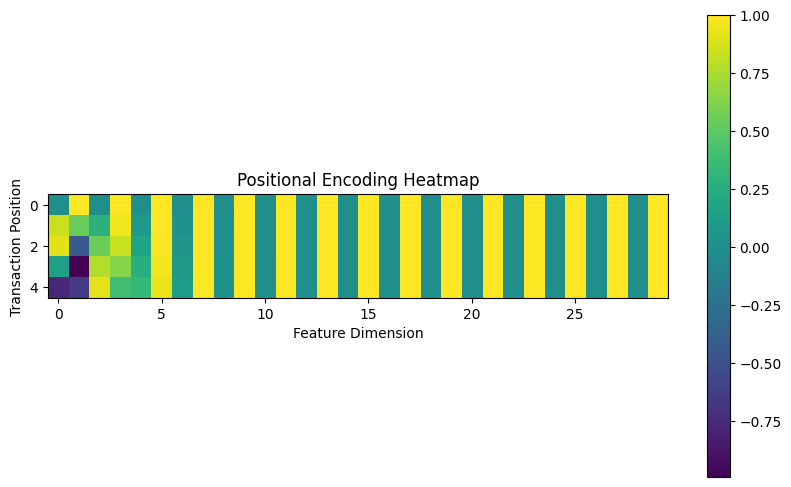

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.imshow(pe)

plt.colorbar()

plt.title("Positional Encoding Heatmap")

plt.xlabel("Feature Dimension")

plt.ylabel("Transaction Position")

plt.show()

In [35]:
X_train_pe = X_train + pe
X_test_pe = X_test + pe

In [36]:
inputs = Input(
    shape=(
        X_train_pe.shape[1],
        X_train_pe.shape[2]
    )
)

x = LSTM(
    64,
    return_sequences=True
)(inputs)

context = AttentionLayer()(x)

x = Dense(
    32,
    activation='relu'
)(context)

outputs = Dense(
    1,
    activation='sigmoid'
)(x)

pe_attention_model = Model(
    inputs,
    outputs
)

pe_attention_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['AUC']
)

In [37]:
history_pe = pe_attention_model.fit(
    X_train_pe,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=256,
    class_weight=class_weights
)

Epoch 1/10
712/712 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - AUC: 0.4973 - loss: 0.7795 - val_AUC: 0.5000 - val_loss: 0.6764
Epoch 2/10
712/712 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - AUC: 0.4744 - loss: 0.7347 - val_AUC: 0.5000 - val_loss: 0.9401
Epoch 3/10
712/712 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - AUC: 0.4938 - loss: 0.7307 - val_AUC: 0.5000 - val_loss: 0.6658
Epoch 4/10
712/712 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - AUC: 0.4913 - loss: 0.7288 - val_AUC: 0.5000 - val_loss: 0.7839
Epoch 5/10
712/712 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - AUC: 0.5137 - loss: 0.7264 - val_AUC: 0.5000 - val_loss: 0.7807
Epoch 6/10
712/712 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - AUC: 0.5085 - loss: 0.7277 - val_AUC: 0.5000 - val_loss: 0.7797
Epoch 7/10
712/712 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - AUC: 0.5141 - loss: 0.7267 - val_AUC: 0.5000 - val_loss: 0.7933
Epoch 8/10
712/712 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - AUC: 0.5151 - loss: 0.7263 - val_AUC: 0.5000 - val_loss: 0.8437
Epoch 9/10
712/712 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step 

In [38]:
evaluate_model(
    pe_attention_model,
    X_test_pe,
    y_test
)

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step
              precision    recall  f1-score   support

           0       0.00      0.00      0.00     56886
           1       0.00      1.00      0.00        75

    accuracy                           0.00     56961
   macro avg       0.00      0.50      0.00     56961
weighted avg       0.00      0.00      0.00     56961

ROC-AUC : 0.5
PR-AUC  : 0.0013166903670932743


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


##Attention Investigation

In [39]:
import tensorflow as tf
from tensorflow.keras.layers import Layer

class AttentionLayerExplainable(Layer):

    def build(self, input_shape):

        self.W = self.add_weight(
            shape=(input_shape[-1],1),
            initializer='random_normal',
            trainable=True
        )

        self.b = self.add_weight(
            shape=(input_shape[1],1),
            initializer='zeros',
            trainable=True
        )

    def call(self, inputs):

        scores = tf.nn.tanh(
            tf.tensordot(
                inputs,
                self.W,
                axes=1
            ) + self.b
        )

        weights = tf.nn.softmax(
            scores,
            axis=1
        )

        context = tf.reduce_sum(
            weights * inputs,
            axis=1
        )

        return context, weights

In [40]:
inputs = Input(
    shape=(SEQ_LEN, FEATURE_DIM)
)

lstm_out = LSTM(
    64,
    return_sequences=True
)(inputs)

context, weights = \
    AttentionLayerExplainable()(lstm_out)

dense = Dense(
    32,
    activation='relu'
)(context)

output = Dense(
    1,
    activation='sigmoid'
)(dense)

fraud_model = Model(
    inputs,
    output
)

In [41]:
attention_extractor = Model(
    inputs=fraud_model.input,
    outputs=weights
)

In [42]:
sample = X_test_pe[0:1]

attention_scores = \
    attention_extractor.predict(sample)

print(attention_scores)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
[[[0.19585456]
  [0.2004502 ]
  [0.20116185]
  [0.20126003]
  [0.20127335]]]


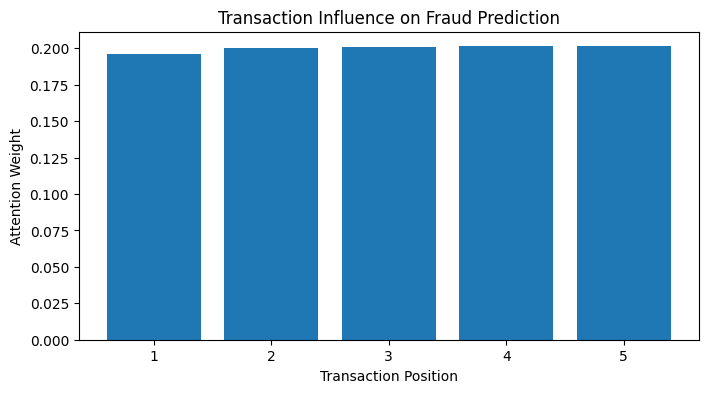

In [43]:
import matplotlib.pyplot as plt

weights = attention_scores[0].flatten()

plt.figure(figsize=(8,4))

plt.bar(
    range(1,len(weights)+1),
    weights
)

plt.xlabel("Transaction Position")

plt.ylabel("Attention Weight")

plt.title(
    "Transaction Influence on Fraud Prediction"
)

plt.show()

##Saving

In [44]:
dense_model.save("dense_model.keras")

print("Dense model saved.")

Dense model saved.


In [45]:
lstm_model.save("lstm_model.keras")

print("LSTM model saved.")

LSTM model saved.


In [46]:
attention_model.save(
    "lstm_attention_model.keras"
)

print("Attention model saved.")

Attention model saved.


In [47]:
pe_attention_model.save(
    "fraud_lstm_attention.keras"
)

print("Final fraud model saved.")

Final fraud model saved.


In [48]:
import joblib

joblib.dump(
    scaler,
    "scaler.pkl"
)

print("Scaler saved.")

Scaler saved.


In [49]:
joblib.dump(
    0.35,
    "threshold.pkl"
)

['threshold.pkl']